# PHYS 2215 — Introduction to Error Propagation

---

## From Analytical Methods to Monte Carlo Simulations

In experimental physics, measured quantities are never known with
perfect precision. When these quantities are used to calculate another
physical quantity, their uncertainties must also be considered.

In this activity, we explore two approaches to uncertainty propagation:

1. **First-order analytical propagation**, using partial derivatives.
2. **Monte Carlo (MC) propagation**, using probability distributions
   and repeated numerical calculations.

We will use a simple pendulum as our primary example.

---

### Learning Outcomes

By completing this activity, you should be able to:

**LO1 — Measurement and Uncertainty**

Interpret measurement uncertainty and distinguish random variability
from systematic effects.

**LO2 — Analytical Propagation**

Explain how uncertainty in measured input quantities influences a
derived physical quantity and apply first-order uncertainty propagation.

**LO3 — Probability Distributions**

Represent measurement uncertainty using probability distributions
and recognize how nonlinear transformations can affect their shape.

**LO4 — Monte Carlo Propagation**

Implement a Monte Carlo simulation and distinguish simulated values
from actual experimental measurements.

**LO5 — Physical Interpretation**

Interpret propagated uncertainty, identify dominant uncertainty
contributions, and evaluate agreement between experimental results
and theoretical predictions.

---

### Prerequisites

- Basic algebra and functions.
- Introductory differentiation.
- Basic familiarity with Python (helpful but not required).
- No prior Monte Carlo experience is assumed.
---

## 1. Why Do We Need Error Propagation?

In experimental physics, we rarely measure the quantity of interest
directly.

Instead, we often measure several physical quantities and combine
them using a mathematical model.

Consider a physical quantity

$$
q=f(x,y),
$$

where $x$ and $y$ are experimentally measured quantities.

Because measurements have uncertainty, we generally report

$$
x=x_0\pm\sigma_x
$$

and

$$
y=y_0\pm\sigma_y.
$$

Here, $\sigma_x$ and $\sigma_y$ represent the standard uncertainties
associated with the measurements.

The central question is:

> How do the uncertainties in $x$ and $y$ affect the uncertainty
> in the calculated quantity $q$?

This is the purpose of **uncertainty propagation**.

### Two Important Types of Uncertainty

**Random uncertainty**

Random variability produces differences between repeated measurements.
For independent measurements, collecting more data can improve the
precision of an estimated mean.

**Systematic uncertainty**

Systematic effects can shift measurements consistently in one direction.
Examples include an incorrectly calibrated ruler or an offset in a
timing device.

Repeating measurements does not necessarily eliminate systematic effects.

### A Measurement Does Not Need to Be Repeated to Have Uncertainty

Suppose a pendulum length is measured once:

$$
L=(0.850\pm0.005)\ \mathrm{m}.
$$

The uncertainty may arise from ruler resolution, the location of
the pivot, or uncertainty in identifying the center of mass.

Even though the length was measured only once, our knowledge of its
actual value is still uncertain.

---

## 2. First-Order Analytical Error Propagation

Consider a function of two variables:

$$
q=f(x,y).
$$

For small changes in $x$ and $y$, we can approximate the corresponding
change in $q$ using a first-order Taylor expansion:

$$
f(x+\delta x,y+\delta y)
\approx
f(x,y)
+
\frac{\partial f}{\partial x}\delta x
+
\frac{\partial f}{\partial y}\delta y.
$$

Therefore,

$$
\delta q\approx
\frac{\partial f}{\partial x}\delta x
+
\frac{\partial f}{\partial y}\delta y.
$$

### Propagating the Variance

For independent measurements, the variance of the sum is the sum of
the individual variances.

Consequently,

$$
\boxed{
\sigma_q^2=
\left(\frac{\partial f}{\partial x}\right)^2\sigma_x^2+
\left(\frac{\partial f}{\partial y}\right)^2\sigma_y^2
}
$$

or, equivalently,

$$
\boxed{
\sigma_q=
\sqrt{
\left(\frac{\partial f}{\partial x}\sigma_x\right)^2+
\left(\frac{\partial f}{\partial y}\sigma_y\right)^2
}
}
$$

This is the **standard (first-order) error propagation formula** commonly used in experimental physics laboratories to estimate the uncertainty in a calculated quantity from the uncertainties in its independently measured input variables.

### Important Assumptions

This expression assumes:

- The uncertainties are sufficiently small for a first-order Taylor
  approximation to be appropriate.
- The two measured quantities are statistically independent.
- The standard uncertainties of the input measurements are known or estimated.

If the measurements are correlated, we must include an additional term:

$$
\sigma_q^2=
\left(\frac{\partial f}{\partial x}\right)^2\sigma_x^2+
\left(\frac{\partial f}{\partial y}\right)^2\sigma_y^2+
2\frac{\partial f}{\partial x}
\frac{\partial f}{\partial y}\operatorname{Cov}(x,y).
$$

Here, $\operatorname{Cov}(x,y)$ is the **covariance** between $x$ and $y$, which describes how their variations are related; it is zero when the two measurements are statistically independent.

**Note:** First-order propagation does not require the input
distributions to be Gaussian.

---

## 3. Worked Example: Measuring Gravity with a Pendulum

For a simple pendulum undergoing small-amplitude oscillations,

$$
T=2\pi\sqrt{\frac{L}{g}}.
$$

Rearranging to calculate gravitational acceleration gives

$$
g(L,T)=\frac{4\pi^2L}{T^2}.
$$

We measure the pendulum length $L$ and period $T$.

### Step 1 — Calculate the Partial Derivatives

The relevant partial derivatives are

$$
\frac{\partial g}{\partial L}=\frac{4\pi^2}{T^2}
$$

and

$$
\frac{\partial g}{\partial T}=-\frac{8\pi^2L}{T^3}.
$$

### Step 2 — Apply the Propagation Formula

Substituting into the first-order propagation equation gives

$$
\sigma_g=
\sqrt{
\left(\frac{4\pi^2}{T^2}\sigma_L\right)^2+
\left(\frac{8\pi^2L}{T^3}\sigma_T\right)^2
}.
$$

Dividing by $g$, we obtain the relative uncertainty:

$$
\boxed{
\frac{\sigma_g}{g}=
\sqrt{
\left(\frac{\sigma_L}{L}\right)^2+
\left(2\frac{\sigma_T}{T}\right)^2
}
}
$$

### Think About It

Why does the relative uncertainty in the period have a factor of two,
while the relative uncertainty in the length does not?

What does this tell us about the sensitivity of the calculated
gravitational acceleration to each measurement?

---

## 4. Describing Experimental Uncertainty

Consider the following illustrative pendulum measurements:

| Quantity | Measured value | Uncertainty information |
|---|---:|---|
| Pendulum length | 0.850 m | ±0.005 m measurement bounds |
| Mean period | 1.850 s | Obtained from 10 independent trials |
| Standard deviation of period trials | 0.020 s | Trial-to-trial variability |

The uncertainties associated with length and period arise from
different measurement processes.

Before assigning probability distributions to our measurements,
we need to distinguish three important concepts.

#### Measurement Bounds (Half-Width)

Suppose we report a measured length as

$$
L=(0.850\pm0.005)\ \mathrm{m}.
$$

If the $\pm0.005$ m represents our estimated measurement bounds,
we are assuming that the actual length lies somewhere between
0.845 m and 0.855 m.

The value 0.005 m is called the **half-width** ($a$) because it
represents half of the total interval:

$$
a=\frac{0.855-0.845}{2}=0.005\ \mathrm{m}.
$$

#### Standard Deviation ($\sigma$)

The standard deviation describes the spread of a probability
distribution around its mean.

Unlike the half-width, the standard deviation depends on how
probability is distributed within the interval.

#### What Does 68% Mean?

For a **normal (Gaussian) distribution**, approximately 68% of
the probability lies within one standard deviation of the mean:

$$
\boxed{\mu-\sigma\leq x\leq\mu+\sigma}.
$$

This is commonly called the *68% interval* or *one-sigma interval*.

However, this relationship is specific to the normal distribution.
For other distributions, the interval containing 68% of the
probability may be different.

For example, in a uniform distribution, the central 68% interval
extends only 68% of the way from the mean to each measurement bound.

**Important:** A central 68% interval contains 68% of the total
probability, not necessarily 68% of the distribution's width.

For a uniform distribution, these percentages coincide because
probability is distributed equally across the interval. For a
normal distribution, probability is concentrated near the mean,
so approximately 68% lies within $\mu\pm\sigma$.


### 4.1 Length: A Single Measurement

Suppose we measure the pendulum length once:

$$
L=(0.850\pm0.005)\ \mathrm{m}.
$$

Here, we interpret $\pm0.005$ m as the estimated measurement
bounds. In other words, we assume the actual length lies somewhere
between 0.845 m and 0.855 m.

Since we have no reason to favor one value within this interval
over another, we assign a **uniform probability distribution**:

$$
L\sim U(0.845,0.855)\ \mathrm{m}.
$$

A uniform distribution assigns equal probability density to
all values within its specified interval.

However, the half-width of a distribution is not the same as its
standard deviation. For a uniform distribution extending from
$a$ to $b$, the standard deviation is given by

$$
\boxed{\sigma=\frac{b-a}{\sqrt{12}}}.
$$

Applying this expression to our length measurement gives

$$
\sigma_L=
\frac{0.855-0.845}{\sqrt{12}}
=
\boxed{0.00289\ \mathrm{m}}.
$$

This is the **standard uncertainty** we will use in our analytical
error propagation calculation.

**Note:** If the original $\pm0.005$ m had already represented
one standard uncertainty rather than measurement bounds, this
conversion would not be necessary.

### 4.2 Period: Repeated Measurements

The period is determined from repeated timing trials.

Suppose the sample standard deviation of the individual period
measurements is

$$
s_T=0.020\ \mathrm{s}.
$$

For $n=10$ independent trials, the estimated standard uncertainty
of the mean is

$$
\boxed{
\sigma_{\bar T}=\frac{s_T}{\sqrt{n}}
}
$$

or

$$
\sigma_{\bar T}=\frac{0.020}{\sqrt{10}}\ \mathrm{s}.
$$

For this introductory example, we model uncertainty in the mean
period using an approximately normal distribution:

$$
T\sim N\left(1.850,\frac{0.020}{\sqrt{10}}\right).
$$

Here, the second parameter represents the standard deviation.

This is a simplifying approximation. In particular, it assumes
independent trials and no significant unaccounted-for systematic
timing bias.

**Why a normal distribution?**

Unlike the pendulum length, the period is estimated from repeated
independent measurements. We assume that the random timing errors
arise from several small contributions, making an approximately
normal distribution a reasonable model.

Furthermore, according to the **Central Limit Theorem**, the
sampling distribution of the mean approaches a normal distribution
as the number of independent measurements increases (provided
the underlying distribution has finite variance).

Thus, for this introductory example, we model our uncertainty
in the mean period as

$$
T\sim N\left(\bar T,\frac{s_T}{\sqrt{n}}\right),
$$

where the second parameter denotes the standard deviation.

With only 10 trials, this is an approximation rather than a
guarantee of normality.

### Important Distinction

The standard deviation of repeated measurements describes their
trial-to-trial variability.

The standard uncertainty of the mean describes our uncertainty
in the estimated average.

These are not interchangeable.

### Analytical Uncertainty Propagation

In the Python script below, we calculate the gravitational acceleration and its standard uncertainty using the first-order analytical error propagation formula derived above.

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Experimental inputs
# --------------------------------------------------

L0 = 0.850                  # Measured length (m)
dL = 0.005                  # Half-width of uniform length distribution (m)

T0 = 1.850                  # Mean period (s)
s_T = 0.020                 # Sample standard deviation of period trials (s)
n_trials = 10

# --------------------------------------------------
# Standard uncertainties
# --------------------------------------------------

sigma_L = 2*dL / np.sqrt(12) #total width is 2xdL
sigma_T = s_T / np.sqrt(n_trials)

# --------------------------------------------------
# Physical model
# --------------------------------------------------

def gravity(L, T):
    return 4 * np.pi**2 * L / T**2

# --------------------------------------------------
# Analytical uncertainty propagation
# --------------------------------------------------

g0 = gravity(L0, T0)

sigma_g = g0 * np.sqrt(
    (sigma_L / L0)**2 +
    (2 * sigma_T / T0)**2
)

print("FIRST-ORDER ANALYTICAL PROPAGATION")
print("----------------------------------")

print(f"g = {g0:.4f} m/s²")
print(f"Standard uncertainty = {sigma_g:.4f} m/s²")
print(f"Relative uncertainty = {100*sigma_g/g0:.3f}%")

FIRST-ORDER ANALYTICAL PROPAGATION
----------------------------------
g = 9.8047 m/s²
Standard uncertainty = 0.0749 m/s²
Relative uncertainty = 0.763%


---

## 5. Why Introduce Monte Carlo Methods?

The standard analytical error propagation formula is a powerful
mathematical tool, but it presents two challenges in an introductory
physics laboratory.

First, it requires **partial derivatives**, a topic from multivariable
calculus that many introductory physics students have not yet studied.

Second, the mathematical procedure can distract from an important
underlying concept: **uncertainty analysis is fundamentally statistical**.
We are not simply manipulating error terms in an equation; we are
investigating how uncertainty in our experimental measurements
influences our knowledge of a calculated physical quantity.

Monte Carlo (MC) methods offer a more intuitive computational
approach. Rather than starting with partial derivatives, we represent
our uncertain measurements using probability distributions, randomly
sample possible values, and propagate those values directly through
the physical model.

In this way, Monte Carlo makes the statistical nature of uncertainty
propagation more visible while requiring only basic algebra,
probability concepts, and introductory Python.

### An Additional Advantage

First-order analytical propagation approximates the physical model
as locally linear. This approximation may become less reliable when:

- Measurement uncertainties are relatively large.
- The physical model is strongly nonlinear.
- Input probability distributions are asymmetric or non-Gaussian.
- We want to examine the complete distribution of a calculated
  quantity rather than only its standard uncertainty.

### The Monte Carlo Idea

Instead of propagating uncertainty using partial derivatives, we
propagate randomly sampled values through the original physical model.

Suppose

$$
q=f(x,y).
$$

We generate many possible values of $x$ and $y$ according to their
assigned probability distributions:

$$
x_1,x_2,\ldots,x_N
$$

and

$$
y_1,y_2,\ldots,y_N.
$$

For each pair, we calculate

$$
q_i=f(x_i,y_i).
$$

After repeating this process many times, we obtain a distribution
of possible values of $q$.

From this distribution, we can determine:

- The mean or median.
- The standard deviation.
- The shape and symmetry of the distribution.
- Probability intervals (e.g., central 68% and 95% intervals).

### Important Distinction

Monte Carlo simulations do not create additional experimental
measurements.

Generating 10,000 simulated values does not mean that we performed
10,000 physical experiments.

Increasing the number of simulations improves the numerical precision
of the simulated distribution. It does not automatically improve the
accuracy or precision of the original experimental measurements.

Monte Carlo propagates the uncertainty model we assign to our inputs.

---

## 6. Implementing a Monte Carlo Simulation

We will now calculate gravitational acceleration using Monte Carlo
uncertainty propagation.

Our physical model remains

$$
g=\frac{4\pi^2L}{T^2}.
$$

### Algorithm

**Step 1:** Choose the number of simulations, $N$.

**Step 2:** Generate $N$ possible pendulum lengths from the assigned
uniform probability distribution.

**Step 3:** Generate $N$ possible mean periods from the assigned
normal probability distribution.

**Step 4:** For each simulated pair $(L_i,T_i)$, calculate

$$
g_i=\frac{4\pi^2L_i}{T_i^2}.
$$

**Step 5:** Examine the resulting distribution of calculated
gravitational accelerations.

For this example, we will use

$$
N=10,000.
$$

### Why Use Random Sampling?

Each simulated pair represents one possible combination of input
values consistent with our measurement uncertainty model.

By repeating the calculation thousands of times, we approximate
how uncertainty in the inputs propagates through the physical model.

For this introductory example, length and period are treated as
statistically independent.

In [9]:
# --------------------------------------------------
# Monte Carlo setup
# --------------------------------------------------

# Reproducible random number generator
rng = np.random.default_rng(2215)

# Number of simulations
N = 10_000

# --------------------------------------------------
# Generate random input values
# --------------------------------------------------

# Length: uniform distribution
L_samples = rng.uniform(
    L0 - dL,
    L0 + dL,
    size=N
)

# Mean period: normal distribution
T_samples = rng.normal(
    T0,
    sigma_T,
    size=N
)

# --------------------------------------------------
# Propagate through the physical model
# --------------------------------------------------

g_samples = gravity(L_samples, T_samples)

# --------------------------------------------------
# Calculate Monte Carlo statistics
# --------------------------------------------------

g_mc = np.mean(g_samples)

sigma_mc = np.std(g_samples, ddof=1)

lower_68, upper_68 = np.percentile(
    g_samples, [16, 84]
)

lower_95, upper_95 = np.percentile(
    g_samples, [2.5, 97.5]
)

print("MONTE CARLO RESULTS")
print("-------------------")

print(f"Mean g = {g_mc:.4f} m/s²")
print(f"Standard uncertainty = {sigma_mc:.4f} m/s²")

print(
    f"Central 68% interval: "
    f"[{lower_68:.4f}, {upper_68:.4f}] m/s²"
)

print(
    f"Central 95% interval: "
    f"[{lower_95:.4f}, {upper_95:.4f}] m/s²"
)

MONTE CARLO RESULTS
-------------------
Mean g = 9.8040 m/s²
Standard uncertainty = 0.0748 m/s²
Central 68% interval: [9.7293, 9.8779] m/s²
Central 95% interval: [9.6568, 9.9509] m/s²


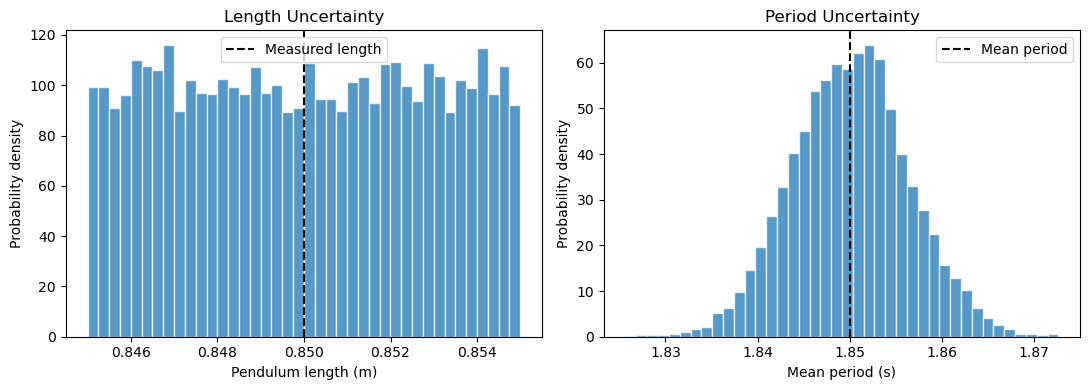

In [10]:
# --------------------------------------------------
# Visualize the sampled input distributions
# --------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Length distribution
axes[0].hist(
    L_samples,
    bins=40,
    density=True,
    edgecolor="white",
    alpha=0.75
)

axes[0].axvline(
    L0,
    color="black",
    linestyle="--",
    label="Measured length"
)

axes[0].set_title("Length Uncertainty")
axes[0].set_xlabel("Pendulum length (m)")
axes[0].set_ylabel("Probability density")
axes[0].legend()

# Period distribution
axes[1].hist(
    T_samples,
    bins=40,
    density=True,
    edgecolor="white",
    alpha=0.75
)

axes[1].axvline(
    T0,
    color="black",
    linestyle="--",
    label="Mean period"
)

axes[1].set_title("Period Uncertainty")
axes[1].set_xlabel("Mean period (s)")
axes[1].set_ylabel("Probability density")
axes[1].legend()

plt.tight_layout()
plt.show()

### Interpreting the Input Distributions

Notice that the two distributions have different shapes.

The length distribution is approximately uniform because we assumed
that every value within the measurement bounds is equally plausible.

The period distribution is approximately Gaussian because we
modeled uncertainty in the mean period using a normal distribution.

These choices should be based on our knowledge of the measurement
process—not simply on convenience.

### Questions

1. Why does the length distribution appear approximately rectangular?

2. Why does the period distribution have a central peak?

3. Would the period distribution become narrower if we increased
   the number of independent timing trials?

4. Would increasing the number of timing trials change the uncertainty
   associated with our measurement of the pendulum length?

5. Why is it important to justify the input distributions before
   performing a Monte Carlo simulation?

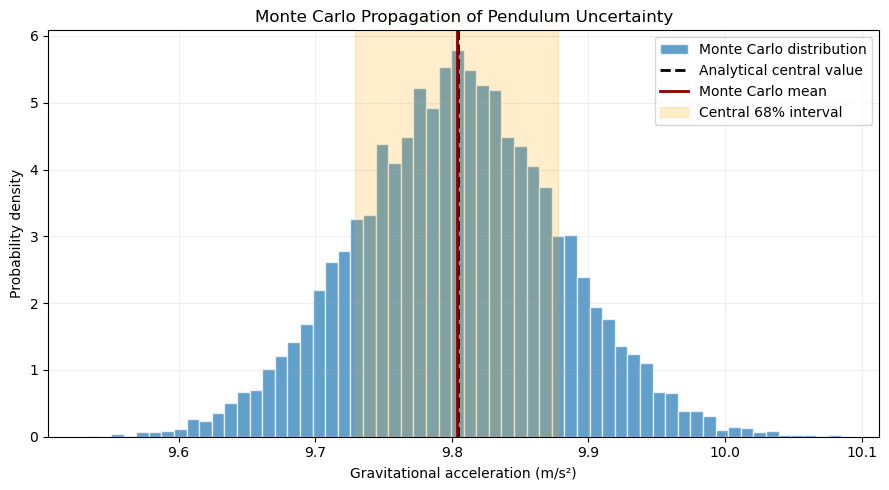

In [11]:
# --------------------------------------------------
# Monte Carlo output distribution
# --------------------------------------------------

plt.figure(figsize=(9, 5))

plt.hist(
    g_samples,
    bins=60,
    density=True,
    alpha=0.70,
    edgecolor="white",
    label="Monte Carlo distribution"
)

# Analytical central value
plt.axvline(
    g0,
    color="black",
    linestyle="--",
    linewidth=2,
    label="Analytical central value"
)

# Monte Carlo mean
plt.axvline(
    g_mc,
    color="darkred",
    linewidth=2,
    label="Monte Carlo mean"
)

# Central 68% probability interval
plt.axvspan(
    lower_68,
    upper_68,
    color="orange",
    alpha=0.20,
    label="Central 68% interval"
)

plt.xlabel("Gravitational acceleration (m/s²)")
plt.ylabel("Probability density")

plt.title("Monte Carlo Propagation of Pendulum Uncertainty")

plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

---

## 7. Comparing Analytical and Monte Carlo Results

We have now calculated gravitational acceleration using two
different approaches.

### Analytical Method

First-order analytical propagation provides an estimate of the
standard uncertainty based on the local behavior of the function.

For the pendulum,

$$
\frac{\sigma_g}{g}=
\sqrt{
\left(\frac{\sigma_L}{L}\right)^2+
\left(2\frac{\sigma_T}{T}\right)^2
}.
$$

### Monte Carlo Method

Monte Carlo propagation provides an approximation to the complete
output distribution.

This allows us to investigate:

- The mean and median of the calculated quantity.
- The standard deviation.
- The shape and symmetry of the distribution.
- Central probability intervals.

For sufficiently small input uncertainties, the analytical and
Monte Carlo standard uncertainties should generally agree closely.

However, close agreement does not establish that the experimental
measurements are accurate or free of systematic effects.

In [12]:
# --------------------------------------------------
# Compare analytical and Monte Carlo results
# --------------------------------------------------

print("ANALYTICAL VS. MONTE CARLO")
print("-" * 62)

print(
    f"{'Quantity':<28}"
    f"{'Analytical':>16}"
    f"{'Monte Carlo':>16}"
)

print("-" * 62)

print(
    f"{'Central value (m/s²)':<28}"
    f"{g0:>16.5f}"
    f"{g_mc:>16.5f}"
)

print(
    f"{'Std. uncertainty (m/s²)':<28}"
    f"{sigma_g:>16.5f}"
    f"{sigma_mc:>16.5f}"
)

difference = 100 * (sigma_mc - sigma_g) / sigma_g

print()
print(
    f"Relative difference in standard uncertainty: "
    f"{difference:.3f}%"
)

ANALYTICAL VS. MONTE CARLO
--------------------------------------------------------------
Quantity                          Analytical     Monte Carlo
--------------------------------------------------------------
Central value (m/s²)                 9.80472         9.80403
Std. uncertainty (m/s²)              0.07485         0.07482

Relative difference in standard uncertainty: -0.043%


---

## 8. Which Measurement Contributes Most to the Uncertainty?

The calculated gravitational acceleration depends on two measured
quantities:

$$
g=\frac{4\pi^2L}{T^2}.
$$

We can use Monte Carlo simulations to investigate their individual
contributions.

We will perform three simulations:

**Simulation A — Length Only**

Vary the length while keeping the period fixed.

$$
g_i=\frac{4\pi^2L_i}{T_0^2}
$$

**Simulation B — Period Only**

Vary the period while keeping the length fixed.

$$
g_i=\frac{4\pi^2L_0}{T_i^2}
$$

**Simulation C — Combined**

Vary both quantities simultaneously.

$$
g_i=\frac{4\pi^2L_i}{T_i^2}
$$

### A Word of Caution

Because the input distributions have different shapes, simply
comparing the apparent widths or heights of their histograms can
be misleading.

Instead, we should compare their **standard uncertainties**.

For the analytical method, the individual relative contributions are

$$
\boxed{
\left(\frac{\sigma_g}{g}\right)_L
=
\frac{\sigma_L}{L}
}
$$

and

$$
\boxed{
\left(\frac{\sigma_g}{g}\right)_T
=
2\frac{\sigma_T}{T}.
}
$$



UNCERTAINTY CONTRIBUTIONS
-----------------------------------------------------
Source                Analytical (%)         MC (%)
-----------------------------------------------------
Length only                   0.3396         0.3395
Period only                   0.6837         0.6837
Combined                      0.7634         0.7653


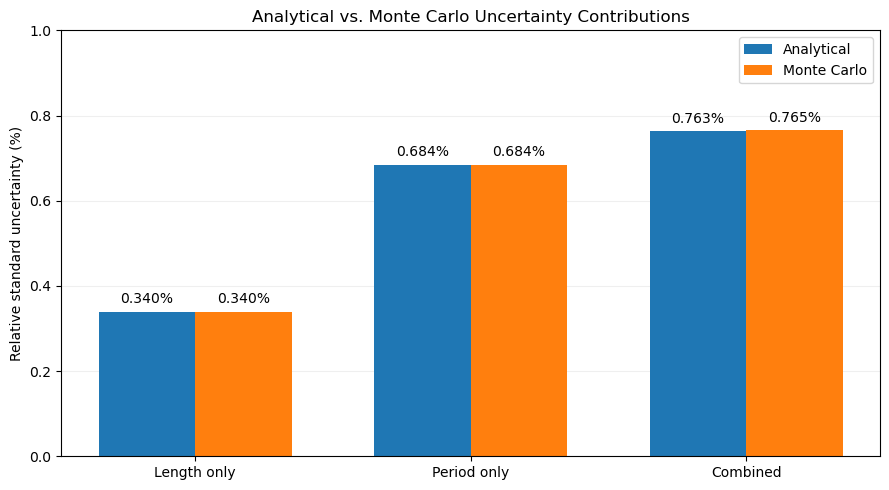

In [18]:
# ==========================================================
# SECTION 8 — COMPARING UNCERTAINTY CONTRIBUTIONS
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# Experimental measurements
# ----------------------------------------------------------

L0 = 0.850                 # Pendulum length (m)
dL = 0.005                 # Half-width of length uncertainty (m)

T0 = 1.850                 # Mean period (s)
s_T = 0.020                # Standard deviation of timing trials (s)
n_trials = 10

# Standard uncertainties
sigma_L = dL / np.sqrt(3)
sigma_T = s_T / np.sqrt(n_trials)

# Physical model
def gravity(L, T):
    return 4 * np.pi**2 * L / T**2

g0 = gravity(L0, T0)

# ----------------------------------------------------------
# 1. Analytical relative standard uncertainties (%)
# ----------------------------------------------------------

analytical_L = 100 * sigma_L / L0

analytical_T = 100 * 2 * sigma_T / T0

analytical_combined = np.sqrt(
    analytical_L**2 + analytical_T**2
)

# ----------------------------------------------------------
# 2. Monte Carlo relative standard uncertainties (%)
# ----------------------------------------------------------

rng = np.random.default_rng(2215)

N = 100_000

# Generate possible input values
L_samples = rng.uniform(
    L0 - dL,
    L0 + dL,
    size=N
)

T_samples = rng.normal(
    T0,
    sigma_T,
    size=N
)

# Individual and combined simulations
g_length_only = gravity(L_samples, T0)

g_period_only = gravity(L0, T_samples)

g_combined = gravity(L_samples, T_samples)

# Relative standard uncertainties (%)
mc_L = 100 * np.std(g_length_only, ddof=1) / g0

mc_T = 100 * np.std(g_period_only, ddof=1) / g0

mc_combined = 100 * np.std(g_combined, ddof=1) / g0

# ----------------------------------------------------------
# 3. Numerical comparison
# ----------------------------------------------------------

labels = [
    "Length only",
    "Period only",
    "Combined"
]

analytical = [
    analytical_L,
    analytical_T,
    analytical_combined
]

monte_carlo = [
    mc_L,
    mc_T,
    mc_combined
]

print("UNCERTAINTY CONTRIBUTIONS")
print("-" * 53)

print(
    f"{'Source':<18}"
    f"{'Analytical (%)':>18}"
    f"{'MC (%)':>15}"
)

print("-" * 53)

for name, a, mc in zip(labels, analytical, monte_carlo):
    print(f"{name:<18}{a:>18.4f}{mc:>15.4f}")

# ----------------------------------------------------------
# 4. Visualization: Analytical vs. Monte Carlo
# ----------------------------------------------------------

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))

# Analytical bars
bars1 = ax.bar(
    x - width/2,
    analytical,
    width,
    label="Analytical"
)

# Monte Carlo bars
bars2 = ax.bar(
    x + width/2,
    monte_carlo,
    width,
    label="Monte Carlo"
)

# Display numerical values above each bar
ax.bar_label(
    bars1,
    fmt="%.3f%%",
    padding=4,
    fontsize=10
)

ax.bar_label(
    bars2,
    fmt="%.3f%%",
    padding=4,
    fontsize=10
)

# Axis formatting
ax.set_xticks(x)
ax.set_xticklabels(labels)

ax.set_ylabel("Relative standard uncertainty (%)")

ax.set_title(
    "Analytical vs. Monte Carlo Uncertainty Contributions"
)

# Set y-axis to 0–1%
ax.set_ylim(0, 1.0)
ax.set_yticks(np.arange(0, 1.1, 0.2))

ax.grid(axis="y", alpha=0.2)
ax.set_axisbelow(True)

ax.legend()

plt.tight_layout()
plt.show()

### Interpreting the Results

The table below summarizes the expected **first-order analytical
relative standard uncertainty contributions** for our pendulum.

| Source | Analytical relative standard uncertainty |
|---|---:|
| Length only | 0.340% |
| Period only | 0.684% |
| Combined | 0.763% |

Notice that the period contributes approximately twice as much
relative standard uncertainty as the length measurement.

This is partly because gravitational acceleration depends on
the inverse square of the period:

$$
g\propto T^{-2}.
$$

The combined standard uncertainty is obtained by adding the
independent contributions in quadrature:

$$
\boxed{
\left(\frac{\sigma_g}{g}\right)_{\mathrm{combined}}
=
\sqrt{(0.340\%)^2+(0.684\%)^2}
\approx 0.763\%.
}
$$

The Monte Carlo results should be close to these analytical
predictions, although small differences arise from finite random
sampling and the nonlinear physical model.

#### Why Are the Analytical and Monte Carlo Results Slightly Different?

The individual length and period contributions should agree very
closely between the two methods.

However, the combined uncertainty may show a small difference
because:

1. **Analytical propagation is a first-order approximation.**
   It approximates the physical model as locally linear, whereas
   Monte Carlo evaluates the original nonlinear relationship:

   $$
   g=\frac{4\pi^2L}{T^2}.
   $$

2. **Monte Carlo uses finite random samples.** Even when the input
   distributions are specified as independent, the generated samples
   may exhibit small accidental correlations and sampling
   fluctuations.

Increasing the number of simulations generally reduces sampling
fluctuations, but it does not eliminate differences arising from
the first-order approximation itself.

### Questions

1. Which input contributes most to the uncertainty in gravitational
   acceleration?

2. Why are the analytical and Monte Carlo contributions nearly
   identical for the individual measurements?

3. Why might the combined Monte Carlo uncertainty differ slightly
   from the analytical result?

4. What happens to the Monte Carlo results if we increase the
   number of simulations from 10,000 to 1,000,000?

5. What would happen to the combined uncertainty if we doubled
   the number of independent timing trials while leaving the
   length measurement unchanged?

---

## 9. What Monte Carlo Cannot Tell Us

Monte Carlo simulations provide a powerful approach to uncertainty
propagation, but they have limitations.

The output distribution depends on:

1. The physical model being used.
2. The input values and their assigned probability distributions.
3. Any correlations between input quantities.
4. The assumptions used to describe the measurement process.

### Random Versus Systematic Effects

Suppose our ruler has an unknown calibration offset.

Repeatedly sampling from a narrow distribution centered on an
incorrect length will not automatically correct this bias.

Likewise, if the pendulum oscillates at a sufficiently large angle,
the small-angle model

$$
T=2\pi\sqrt{\frac{L}{g}}
$$

may no longer describe the experiment adequately.

Increasing the number of Monte Carlo simulations will not correct
an incomplete physical model.

### Key Takeaway

> Monte Carlo propagates our knowledge of the inputs through a
> physical model. The reliability of the result depends on the
> quality of both the input uncertainty model and the physics.

---

## 10. Independent Application: Kinetic Energy

We will now apply the same uncertainty-propagation methodology
to a different physical problem.

This exercise is intended to test whether you can transfer the
method to a new physical context.

### The Problem

The kinetic energy of a moving object is

$$
K=\frac12mv^2.
$$

Suppose we obtain the following experimental measurements:

$$
m=(0.250\pm0.005)\ \mathrm{kg}
$$

and

$$
v=(2.00\pm0.10)\ \mathrm{m/s}.
$$

For this exercise, treat the stated uncertainties as standard
uncertainties and assume that mass and velocity are independent
and normally distributed.

### Part A — Analytical Propagation

1. Calculate the nominal kinetic energy.

2. Determine the partial derivatives

$$
\frac{\partial K}{\partial m}
\qquad\text{and}\qquad
\frac{\partial K}{\partial v}.
$$

3. Show that the relative first-order uncertainty is

$$
\boxed{
\frac{\sigma_K}{K}=
\sqrt{
\left(\frac{\sigma_m}{m}\right)^2+
\left(2\frac{\sigma_v}{v}\right)^2
}
}.
$$

4. Calculate the analytical standard uncertainty in kinetic energy.

### Part B — Monte Carlo Propagation

Using Python:

1. Generate 10,000 possible mass measurements.
2. Generate 10,000 possible velocity measurements.
3. Calculate the kinetic energy for each simulated pair.
4. Plot a histogram of the resulting kinetic-energy distribution.
5. Calculate the mean, standard deviation, and central 68% interval.
6. Compare the result with the analytical calculation.

### Part C — Exploring Nonlinearity

Increase the uncertainty in velocity from

$$
\sigma_v=0.10\ \mathrm{m/s}
$$

to

$$
\sigma_v=0.50\ \mathrm{m/s}.
$$

Repeat the Monte Carlo simulation.

### Questions

1. Does the resulting kinetic-energy distribution remain symmetric?

2. How does the agreement between analytical and Monte Carlo
   propagation change?

3. Why does increasing the velocity uncertainty have a particularly
   significant effect on the calculated kinetic energy?

4. Which method provides more information about the shape of
   the resulting uncertainty distribution?

In [14]:
# ==================================================
# INDEPENDENT EXERCISE: KINETIC ENERGY
# ==================================================

# Experimental measurements
m0 = 0.250
sigma_m = 0.005

v0 = 2.00
sigma_v = 0.10

N = 10_000

# --------------------------------------------------
# PART A: Analytical propagation
# --------------------------------------------------

def kinetic_energy(m, v):
    return 0.5 * m * v**2

K0 = kinetic_energy(m0, v0)

# TODO: Calculate the analytical standard uncertainty

sigma_K_analytical = ...


# --------------------------------------------------
# PART B: Monte Carlo propagation
# --------------------------------------------------

rng = np.random.default_rng(2215)

# TODO: Generate random mass and velocity samples

m_samples = ...

v_samples = ...

# TODO: Calculate the kinetic-energy distribution

K_samples = ...


# --------------------------------------------------
# PART C: Calculate summary statistics
# --------------------------------------------------

K_mean = ...
K_std = ...

# TODO: Calculate the central 68% interval


# --------------------------------------------------
# PART D: Visualization
# --------------------------------------------------

# TODO: Plot the kinetic-energy distribution


# --------------------------------------------------
# PART E: Investigating nonlinearity
# --------------------------------------------------

# Increase the velocity uncertainty to 0.50 m/s
# and repeat the simulation.

---

## 11. Final Reflection

Answer the following questions in your own words.

### Conceptual Understanding

**1.** Explain the difference between measurement variability and
uncertainty in an estimated mean.

**2.** What assumptions are made when using first-order analytical
uncertainty propagation?

**3.** Why can nonlinear physical relationships produce asymmetric
output distributions, even when the input distributions are symmetric?

### Computational Understanding

**4.** Describe the basic steps involved in a Monte Carlo uncertainty
propagation simulation.

**5.** Why does generating 10,000 simulated values not mean that we
have performed 10,000 experimental measurements?

**6.** What happens when we increase the number of simulations from
10,000 to 100,000? Does this necessarily improve our knowledge
of the original experimental measurements?

### Physical Interpretation

**7.** Why is it important to justify the input probability
distributions before performing a simulation?

**8.** How can we identify which experimental measurement contributes
most to the uncertainty in a calculated quantity?

**9.** If an experimental result agrees with a theoretical value
within its reported uncertainty, does this prove that the physical
model is correct? Explain.

---

## Summary

First-order analytical uncertainty propagation uses partial
derivatives to approximate how input uncertainties influence a
calculated physical quantity.

Monte Carlo propagation instead samples possible input values
from assigned probability distributions and repeatedly evaluates
the original physical model.

Both methods provide valuable information.

Analytical propagation offers a convenient mathematical estimate
when the local linear approximation is adequate.

Monte Carlo provides an approximation to the complete output
distribution and is particularly useful when dealing with
nonlinear models, non-Gaussian inputs, or asymmetric results.

**Neither method replaces careful experimentation or a physically
justified measurement model.**

---